In [21]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from torch.nn.utils.rnn import pad_sequence
import torch.nn.functional as F
import math
import time

import numpy as np
import pandas as pd
from collections import Counter
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import re
import warnings
warnings.filterwarnings('ignore')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cpu


# News classification using LSTM, Transformer and AG News dataset

In [2]:
from datasets import load_dataset
dataset = load_dataset("fancyzhx/ag_news")

print(f"Training samples: {len(dataset['train'])}")
print(f"Test samples: {len(dataset['test'])}")


# sampling train and test data
train_size = 5000
test_size = 1000

train_texts = dataset['train']['text'][:train_size]
train_labels = dataset['train']['label'][:train_size]

test_texts = dataset['test']['text'][:test_size]
test_labels = dataset['test']['label'][:test_size]

class_names = dataset['train'].features['label'].names
print(f"Class names: {class_names}")

Training samples: 120000
Test samples: 7600
Class names: ['World', 'Sports', 'Business', 'Sci/Tech']


In [3]:
import random

# create paired data and shuffle
train_pairs = list(zip(train_texts, train_labels))
random.seed(42)
random.shuffle(train_pairs)

train_texts = [pair[0] for pair in train_pairs]
train_labels = [pair[1] for pair in train_pairs]

test_pairs = list(zip(test_texts, test_labels))
random.shuffle(test_pairs)
test_texts = [pair[0] for pair in test_pairs]
test_labels = [pair[1] for pair in test_pairs]

# verify distribution
print("\nLabel distribution after shuffling:")
train_counter = Counter(train_labels)
for i, name in enumerate(class_names):
    print(f"  {name}: {train_counter[i]} samples")


Label distribution after shuffling:
  World: 1235 samples
  Sports: 1032 samples
  Business: 1236 samples
  Sci/Tech: 1497 samples


In [4]:
from nltk.corpus import stopwords
import nltk
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

def clean_text(text): # this function cleans text by converting to lowercase, removing stopwords and non alphabetic letters

    text = text.lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    words = text.split()
    words = [w for w in words if w not in stop_words]
    return ' '.join(words)


train_texts_clean = [clean_text(text) for text in train_texts]
test_texts_clean = [clean_text(text) for text in test_texts]


# building vocabulary
def build_vocab(texts, min_freq=2, max_size=25000):

    counter = Counter()
    for text in texts:
        tokens = text.split()
        counter.update(tokens)
    
    # include special tokens
    vocab = {
        '<PAD>': 0,
        '<UNK>': 1,
        '<SOS>': 2,
        '<EOS>': 3
    }
    
    # add frequent words
    most_common = counter.most_common(max_size - len(vocab))
    for word, _ in most_common:
        if counter[word] >= min_freq:
            vocab[word] = len(vocab)
    
    return vocab

vocab = build_vocab(train_texts_clean, min_freq=2, max_size=25000)
vocab_size = len(vocab)
print(f"Vocabulary size is: {vocab_size}")
print(f"Sample vocab entries: {list(vocab.items())[:10]}")


def text_to_indices(text, vocab, max_len=None):
    tokens = text.split()
    indices = [vocab.get(token, vocab['<UNK>']) for token in tokens]
    return indices



def pad_sequences(sequences, max_len, pad_val=0): # padding sequencies to same length
    
    padded = []
    for seq in sequences:
        if len(seq) > max_len:
            seq = seq[:max_len]
        else:
            seq = seq + [pad_val] * (max_len - len(seq))
        padded.append(seq)
    return np.array(padded, dtype=np.int64)


train_indices = [text_to_indices(text, vocab) for text in train_texts_clean]
test_indices = [text_to_indices(text, vocab) for text in test_texts_clean]

# sequence length distribution
lengths = [len(seq) for seq in train_indices]
print(f"Mean sequence length: {np.mean(lengths):.2f}")
print(f"Max sequence length: {np.max(lengths)}")
print(f"90th percentile: {np.percentile(lengths, 90):.2f}")

Vocabulary size is: 9896
Sample vocab entries: [('<PAD>', 0), ('<UNK>', 1), ('<SOS>', 2), ('<EOS>', 3), ('reuters', 4), ('us', 5), ('ap', 6), ('new', 7), ('said', 8), ('tuesday', 9)]
Mean sequence length: 25.67
Max sequence length: 90
90th percentile: 34.00


[nltk_data] Downloading package stopwords to /home/zahra/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [5]:

print("\nDATA CONSISTENCY CHECK")
print(f"Sample original text: {train_texts[0][:200]}...")
print(f"Sample cleaned text: {train_texts_clean[0][:200]}...")
print(f"Sample indices: {text_to_indices(train_texts_clean[0], vocab)[:20]}")
print(f"Sample label: {train_labels[0]} - {class_names[train_labels[0]]}")

# check vocabulary coverage
all_tokens = set()
for text in train_texts_clean[:100]:
    all_tokens.update(text.split())
covered = sum(1 for token in all_tokens if token in vocab)
print(f"Vocabulary coverage (first 100 samples): {covered}/{len(all_tokens)} = {covered/len(all_tokens)*100:.2f}%")



DATA CONSISTENCY CHECK
Sample original text: Iraqi Delegation Flies to Najaf in Peace Bid  BAGHDAD (Reuters) - A delegation of Iraqi political and  religious leaders flew out of Baghdad on U.S. military  helicopters Tuesday, heading for Najaf in...
Sample cleaned text: iraqi delegation flies najaf peace bid baghdad reuters delegation iraqi political religious leaders flew baghdad us military helicopters tuesday heading najaf bid end bloody shiite uprising delegates ...
Sample indices: [110, 781, 4068, 40, 174, 277, 221, 4, 781, 110, 461, 1068, 546, 3535, 221, 5, 256, 7043, 9, 2195]
Sample label: 0 - World
Vocabulary coverage (first 100 samples): 1391/1525 = 91.21%


In [6]:
class AGNewsDataset(Dataset):
    def __init__(self, texts, labels, vocab, max_len):
        self.texts = texts
        self.labels = labels
        self.vocab = vocab
        self.max_len = max_len
    
    def __len__(self):
        return len(self.texts)
    
    def __getitem__(self, idx):
        indices = text_to_indices(self.texts[idx], self.vocab)
        if len(indices) > self.max_len:
            indices = indices[:self.max_len]
        else:
            indices = indices + [self.vocab['<PAD>']] * (self.max_len - len(indices))
        
        return torch.tensor(indices, dtype=torch.long), torch.tensor(self.labels[idx], dtype=torch.long)

def create_dataloaders(train_texts, train_labels, test_texts, test_labels, vocab, max_len, batch_size=64):

    train_dataset = AGNewsDataset(train_texts, train_labels, vocab, max_len)
    test_dataset = AGNewsDataset(test_texts, test_labels, vocab, max_len)
    
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
    
    return train_loader, test_loader

### News classification with LSTM

In [7]:
# LSTM Model 
class LSTMModel(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_size, num_layers=2, num_classes=4, dropout=0.5):
        super(LSTMModel, self).__init__()
        
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)

        nn.init.uniform_(self.embedding.weight, -0.1, 0.1)
        nn.init.constant_(self.embedding.weight[vocab['<PAD>']], 0)  # Pad token should be zero

        self.lstm = nn.LSTM(
            input_size=embedding_dim,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0,
            bidirectional=True
        )
        lstm_output_size = hidden_size * 2
        
        for name, param in self.lstm.named_parameters():
            if 'weight_ih' in name:
                nn.init.xavier_uniform_(param)
            elif 'weight_hh' in name:
                nn.init.orthogonal_(param)
            elif 'bias' in name:
                nn.init.zeros_(param)
        
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(lstm_output_size, num_classes)
        nn.init.xavier_uniform_(self.fc.weight)
        nn.init.zeros_(self.fc.bias)
    
    def forward(self, x):
        embedded = self.embedding(x)  # (batch_size, seq_len, embedding_dim)   
        lstm_out, (h_n, c_n) = self.lstm(embedded)
        # for bidirectional: concatenate forward and backward last hidden states
        if self.lstm.bidirectional:
            # h_n shape: (num_layers * 2, batch, hidden_size)
            last_hidden = torch.cat((h_n[-2], h_n[-1]), dim=1)  # (batch, hidden_size * 2)
        else:
            last_hidden = h_n[-1]
        
        dropped = self.dropout(last_hidden)
        output = self.fc(dropped)
        
        return output

In [8]:
# training and evaluating
def train_epoch(model, dataloader, optimizer, criterion, device):
    model.train()
    total_loss = 0
    correct = 0
    total = 0
    
    for batch_idx, (data, targets) in enumerate(dataloader):
        data, targets = data.to(device), targets.to(device)
        
        optimizer.zero_grad()
        outputs = model(data)
        loss = criterion(outputs, targets)
        loss.backward()
         # gradient clipping to prevent exploding gradients
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        
        total_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total += targets.size(0)
        correct += (predicted == targets).sum().item()
    
    return total_loss / len(dataloader), 100 * correct / total

def evaluate(model, dataloader, criterion, device):
    model.eval()
    total_loss = 0
    correct = 0
    total = 0
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for data, targets in dataloader:
            data, targets = data.to(device), targets.to(device)
            outputs = model(data)
            loss = criterion(outputs, targets)
            
            total_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += targets.size(0)
            correct += (predicted == targets).sum().item()
            
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(targets.cpu().numpy())
    
    accuracy = 100 * correct / total
    precision, recall, f1, _ = precision_recall_fscore_support(
        all_labels, all_preds, average='weighted'
    )
    
    return total_loss / len(dataloader), accuracy, precision, recall, f1, all_preds, all_labels

def train_model(model, train_loader, test_loader, epochs, lr, device):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5) # use Adam with weight decay (L2 regularization)
    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5) # learning rate scheduler
    
    train_losses = []
    train_accs = []
    test_losses = []
    test_accs = []
    test_f1s = []
    
    best_acc = 0
    best_model_state = None
    
    for epoch in range(epochs):
        train_loss, train_acc = train_epoch(model, train_loader, optimizer, criterion, device)
        test_loss, test_acc, precision, recall, f1, _, _ = evaluate(model, test_loader, criterion, device)
        
        train_losses.append(train_loss)
        train_accs.append(train_acc)
        test_losses.append(test_loss)
        test_accs.append(test_acc)
        test_f1s.append(f1)
        
        print(f'Epoch {epoch+1}/{epochs}: '
              f'Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%, '
              f'Test Loss: {test_loss:.4f}, Test Acc: {test_acc:.2f}%, F1: {f1:.4f}')
        
        if test_acc > best_acc:
            best_acc = test_acc
            best_model_state = model.state_dict().copy()

        scheduler.step()
    
    # loading best model
    model.load_state_dict(best_model_state)
    
    return {
        'train_losses': train_losses,
        'train_accs': train_accs,
        'test_losses': test_losses,
        'test_accs': test_accs,
        'test_f1s': test_f1s,
        'best_acc': best_acc
    }

In [13]:
# experiment with different hidden sizes
def experiment_hidden_sizes(hidden_sizes, embedding_dim=128, max_len=100, batch_size=64, epochs=10, lr=1e-3):
    results = {}
    
    for hidden_size in hidden_sizes:
        print(f"Experiment with Hidden Size = {hidden_size}")
        
        train_loader, test_loader = create_dataloaders(
            train_texts_clean, train_labels,
            test_texts_clean, test_labels,
            vocab, max_len, batch_size
        )
        
        model = LSTMModel(
            vocab_size=vocab_size,
            embedding_dim=embedding_dim,
            hidden_size=hidden_size,
            num_layers=2,
            num_classes=4,
            dropout=0.5
        ).to(device)
        
        total_params = sum(p.numel() for p in model.parameters())
        print(f"Total parameters: {total_params:,}")
        
        history = train_model(model, train_loader, test_loader, epochs, lr, device)
        history['hidden_size'] = hidden_size
        history['params'] = total_params
        
        criterion = nn.CrossEntropyLoss()
        test_loss, test_acc, precision, recall, f1, preds, labels = evaluate(
            model, test_loader, criterion, device
        )
        
        history['final_metrics'] = {
            'accuracy': test_acc,
            'precision': precision,
            'recall': recall,
            'f1': f1
        }
        history['preds'] = preds
        history['labels'] = labels
        
        results[hidden_size] = history
    
    return results

hidden_sizes = [4, 16, 64]
hidden_results = experiment_hidden_sizes(hidden_sizes, epochs=10)

Experiment with Hidden Size = 4
Total parameters: 1,271,460
Epoch 1/10: Train Loss: 1.3691, Train Acc: 32.10%, Test Loss: 1.3568, Test Acc: 27.60%, F1: 0.1451
Epoch 2/10: Train Loss: 1.1890, Train Acc: 46.58%, Test Loss: 1.0982, Test Acc: 60.50%, F1: 0.5217
Epoch 3/10: Train Loss: 0.9451, Train Acc: 61.50%, Test Loss: 0.9439, Test Acc: 67.30%, F1: 0.6207
Epoch 4/10: Train Loss: 0.8110, Train Acc: 68.46%, Test Loss: 0.8760, Test Acc: 71.80%, F1: 0.6971
Epoch 5/10: Train Loss: 0.7350, Train Acc: 71.66%, Test Loss: 0.8444, Test Acc: 74.80%, F1: 0.7420
Epoch 6/10: Train Loss: 0.6969, Train Acc: 74.76%, Test Loss: 0.8196, Test Acc: 77.90%, F1: 0.7752
Epoch 7/10: Train Loss: 0.6682, Train Acc: 75.06%, Test Loss: 0.8422, Test Acc: 78.00%, F1: 0.7742
Epoch 8/10: Train Loss: 0.6502, Train Acc: 77.40%, Test Loss: 0.8018, Test Acc: 78.90%, F1: 0.7857
Epoch 9/10: Train Loss: 0.6290, Train Acc: 76.72%, Test Loss: 0.7928, Test Acc: 79.10%, F1: 0.7892
Epoch 10/10: Train Loss: 0.6029, Train Acc: 78.48

In [11]:
# experiment with different sequence lengths
def experiment_sequence_lengths(seq_lengths, hidden_size=128, embedding_dim=128, batch_size=64, epochs=10, lr=1e-3):
    results = {}
    
    for seq_len in seq_lengths:
        print(f"Experiment with Sequence Length = {seq_len}")
        
        train_loader, test_loader = create_dataloaders(
            train_texts_clean, train_labels,
            test_texts_clean, test_labels,
            vocab, seq_len, batch_size
        )
        
        model = LSTMModel(
            vocab_size=vocab_size,
            embedding_dim=embedding_dim,
            hidden_size=hidden_size,
            num_layers=2,
            num_classes=4,
            dropout=0.5
        ).to(device)
        
        history = train_model(model, train_loader, test_loader, epochs, lr, device)
        history['seq_len'] = seq_len
        
        criterion = nn.CrossEntropyLoss()
        test_loss, test_acc, precision, recall, f1, preds, labels = evaluate(
            model, test_loader, criterion, device
        )
        
        history['final_metrics'] = {
            'accuracy': test_acc,
            'precision': precision,
            'recall': recall,
            'f1': f1
        }
        history['preds'] = preds
        history['labels'] = labels
        
        results[seq_len] = history
    
    return results

max_seq_lengths = [10, 50, 100]
seq_length_results = experiment_sequence_lengths(max_seq_lengths, epochs=10)

Experiment with Sequence Length = 10
Epoch 1/10: Train Loss: 1.0255, Train Acc: 54.26%, Test Loss: 0.6548, Test Acc: 75.30%, F1: 0.7500
Epoch 2/10: Train Loss: 0.3459, Train Acc: 88.92%, Test Loss: 0.6255, Test Acc: 78.00%, F1: 0.7791
Epoch 3/10: Train Loss: 0.1678, Train Acc: 94.70%, Test Loss: 0.7179, Test Acc: 76.50%, F1: 0.7665
Epoch 4/10: Train Loss: 0.0943, Train Acc: 97.16%, Test Loss: 0.8339, Test Acc: 76.40%, F1: 0.7662
Epoch 5/10: Train Loss: 0.0647, Train Acc: 98.06%, Test Loss: 1.0133, Test Acc: 73.30%, F1: 0.7356
Epoch 6/10: Train Loss: 0.0328, Train Acc: 99.02%, Test Loss: 1.1112, Test Acc: 75.50%, F1: 0.7560
Epoch 7/10: Train Loss: 0.0226, Train Acc: 99.40%, Test Loss: 1.1637, Test Acc: 75.50%, F1: 0.7561
Epoch 8/10: Train Loss: 0.0179, Train Acc: 99.48%, Test Loss: 1.2525, Test Acc: 75.80%, F1: 0.7593
Epoch 9/10: Train Loss: 0.0170, Train Acc: 99.50%, Test Loss: 1.3332, Test Acc: 74.40%, F1: 0.7448
Epoch 10/10: Train Loss: 0.0136, Train Acc: 99.58%, Test Loss: 1.3700, T

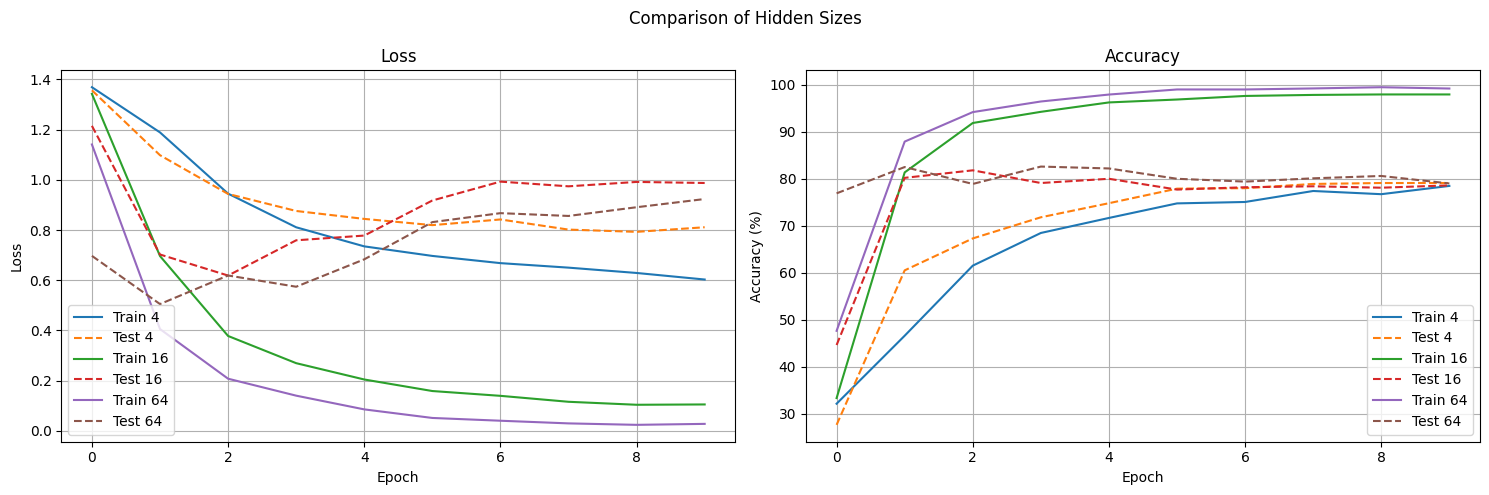

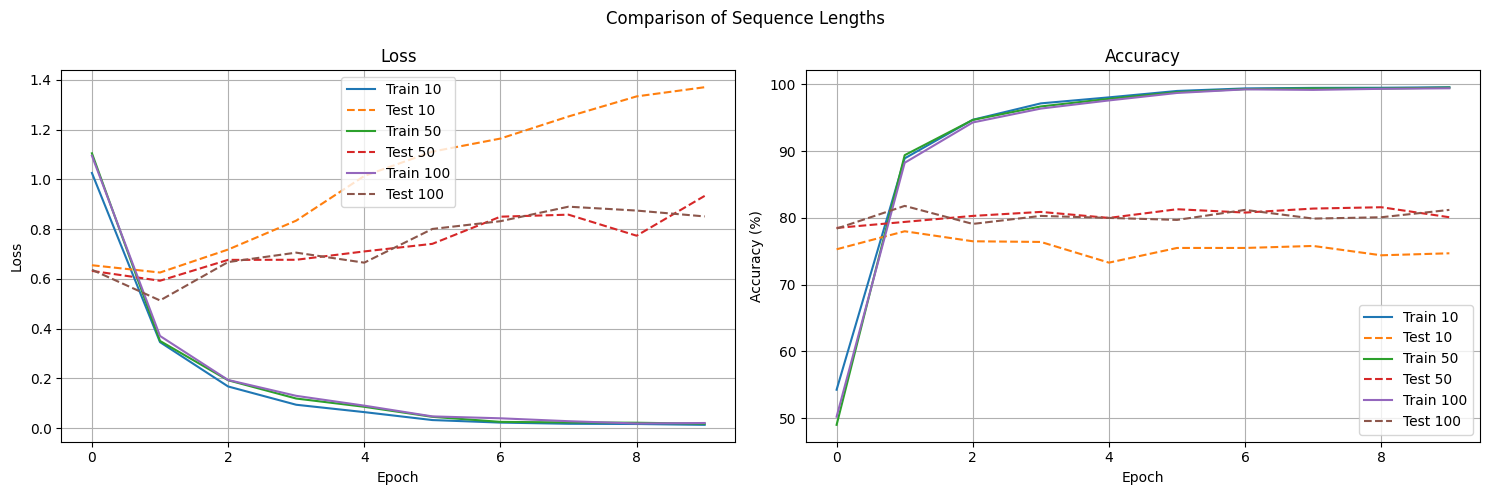


Best Hidden Size: 64


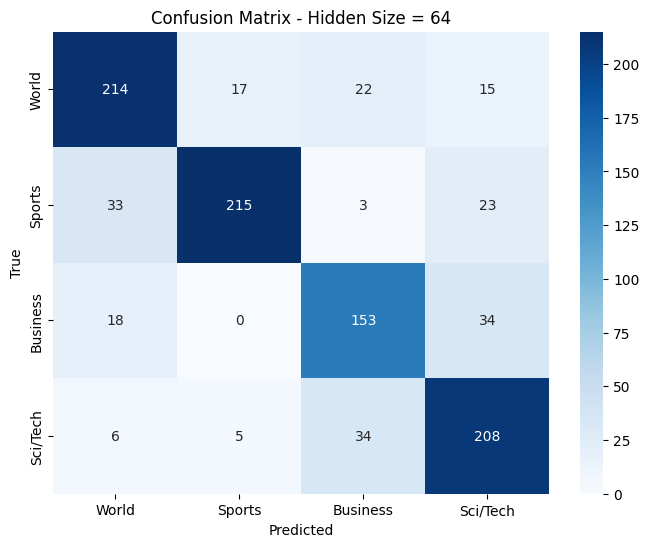


Final Results with Hidden Size = 64
----------------------------------------
Accuracy: 79.00%
Precision: 0.7961
Recall: 0.7900
F1-Score: 0.7913


In [16]:

def plot_training_history(histories, title, metric='accuracy'):

    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    
    for key, history in histories.items():
        label = str(key)
        axes[0].plot(history['train_losses'], label=f'Train {label}')
        axes[0].plot(history['test_losses'], '--', label=f'Test {label}')
        axes[1].plot(history['train_accs'], label=f'Train {label}')
        axes[1].plot(history['test_accs'], '--', label=f'Test {label}')
    
    axes[0].set_title('Loss')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].legend()
    axes[0].grid(True)
    
    axes[1].set_title('Accuracy')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy (%)')
    axes[1].legend()
    axes[1].grid(True)
    
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

def plot_confusion_matrix(labels, preds, class_names, title):

    cm = confusion_matrix(labels, preds)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=class_names, yticklabels=class_names)
    plt.title(f'Confusion Matrix - {title}')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.show()
    return cm

def print_metrics(metrics, title):

    print(f"\n{title}")
    print("-" * 40)
    print(f"Accuracy: {metrics['accuracy']:.2f}%")
    print(f"Precision: {metrics['precision']:.4f}")
    print(f"Recall: {metrics['recall']:.4f}")
    print(f"F1-Score: {metrics['f1']:.4f}")

# plot results
plot_training_history(hidden_results, 'Comparison of Hidden Sizes')
plot_training_history(seq_length_results, 'Comparison of Sequence Lengths')

# best model results
best_hidden = max(hidden_results.keys(), key=lambda k: hidden_results[k]['best_acc'])
print(f"\nBest Hidden Size: {best_hidden}")

best_result = hidden_results[best_hidden]
plot_confusion_matrix(
    best_result['labels'], 
    best_result['preds'], 
    class_names,
    f'Hidden Size = {best_hidden}'
)

print_metrics(best_result['final_metrics'], f"Final Results with Hidden Size = {best_hidden}")

In [20]:

# error analysis function (analyzing misclassified samples)
def analyze_errors(texts, labels, preds, class_names, num_samples=10):

    errors = []
    for i, (true, pred) in enumerate(zip(labels, preds)):
        if true != pred:
            errors.append({
                'text': texts[i],
                'true': class_names[true],
                'pred': class_names[pred],
                'idx': i
            })
    
    print(f"\nTotal errors: {len(errors)}")
    print(f"Error rate: {len(errors)/len(labels)*100:.2f}%")
    
    print(f"\nError samples:")
    for i, error in enumerate(errors[:num_samples]):
        print(f"\n--- Sample {i+1} ---")
        print(f"Text: {error['text'][:200]}...")
        print(f"True class: {error['true']}")
        print(f"Predicted class: {error['pred']}")
    
    # analyze error patterns
    error_pairs = {}
    for error in errors:
        key = f"{error['true']} -> {error['pred']}"
        error_pairs[key] = error_pairs.get(key, 0) + 1
    
    print(f"\nCommon error patterns:")
    for pair, count in sorted(error_pairs.items(), key=lambda x: x[1], reverse=True)[:5]:
        print(f"  {pair}: {count} times")
    
    return errors

# analyze errors for best model
errors = analyze_errors(test_texts, best_result['labels'], best_result['preds'], class_names)


Total errors: 210
Error rate: 21.00%

Error samples:

--- Sample 1 ---
Text: Iraq group to free 3 Indians, 4 others of Kuwait firm - TV (Reuters) Reuters - Iraqi kidnappers of seven employees of a Kuwaiti company said in a video statement on Thursday they would release the cap...
True class: World
Predicted class: Business

--- Sample 2 ---
Text: Bovina wins Pilot Pen tournament Elena Bovina of Russia outlasted Nathalie Dechy of France 6-2, 2-6, 7-5 and won the Pilot Pen tennis tournament Saturday. Bovina, seeded seventh, won her third WTA tit...
True class: Sports
Predicted class: World

--- Sample 3 ---
Text: A blazing start for Beijing Greece tried to pass the Olympics baton off to Beijing on Sunday night, but it was a tough job. The Chinese are way ahead of the curve already....
True class: Sports
Predicted class: World

--- Sample 4 ---
Text: Seattle Mariners Minor League Report - August 23rd TACOMA RAINIERS - The Rainiers just missed a perfect week when they suffered their only 

### News classification with Transformer

In [24]:
# positional encoding

class PositionalEncoding(nn.Module): # this function implements positional encoding as described in "Attention Is All You Need" paper because Self-Attention doesn't consider token order by itself
 
    def __init__(self, d_model, max_len=5000):
        super(PositionalEncoding, self).__init__()
        # create positional encoding matrix
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        # compute using sine and cosine functions
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        
        pe = pe.unsqueeze(0)  # (1, max_len, d_model)
        self.register_buffer('pe', pe)
        
    def forward(self, x):
        return x + self.pe[:, :x.size(1), :] # concatenate positional encoding with embedding

In [25]:

# Multi Head Self-Attention 
class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, num_heads, dropout=0.1):
        super(MultiHeadAttention, self).__init__()
        
        assert d_model % num_heads == 0, "d_model must be divisible by num_heads"
        
        self.d_model = d_model
        self.num_heads = num_heads
        self.d_k = d_model // num_heads
        
        self.W_q = nn.Linear(d_model, d_model)
        self.W_k = nn.Linear(d_model, d_model)
        self.W_v = nn.Linear(d_model, d_model)
        self.W_o = nn.Linear(d_model, d_model)
        
        self.dropout = nn.Dropout(dropout)
        
    def scaled_dot_product_attention(self, Q, K, V, mask=None):
       
        scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(self.d_k) # scaled dot product
        
        if mask is not None:
            scores = scores.masked_fill(mask == 0, -1e9)
        
        attention_weights = F.softmax(scores, dim=-1)
        attention_weights = self.dropout(attention_weights)
        
        output = torch.matmul(attention_weights, V)
        return output, attention_weights
    
    def forward(self, x, mask=None):
        batch_size, seq_len, _ = x.size()
        
        # compute Q, K, V
        Q = self.W_q(x).view(batch_size, seq_len, self.num_heads, self.d_k).transpose(1, 2)
        K = self.W_k(x).view(batch_size, seq_len, self.num_heads, self.d_k).transpose(1, 2)
        V = self.W_v(x).view(batch_size, seq_len, self.num_heads, self.d_k).transpose(1, 2)
        
        # compute attention
        attn_output, attn_weights = self.scaled_dot_product_attention(Q, K, V, mask)
        
        # concatenate heads
        attn_output = attn_output.transpose(1, 2).contiguous().view(batch_size, seq_len, self.d_model)
        output = self.W_o(attn_output)
        
        return output, attn_weights

In [ ]:
# Transformer Encoder block
class TransformerEncoderBlock(nn.Module):
    def __init__(self, d_model, num_heads, d_ff, dropout=0.1):
        super(TransformerEncoderBlock, self).__init__()
        
        self.self_attention = MultiHeadAttention(d_model, num_heads, dropout)
        self.feed_forward = nn.Sequential(
            nn.Linear(d_model, d_ff),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(d_ff, d_model)
        )
        
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.dropout1 = nn.Dropout(dropout)
        self.dropout2 = nn.Dropout(dropout)
        
    def forward(self, x, mask=None):
        # self-attention with residual connection
        attn_output, attn_weights = self.self_attention(x, mask)
        x = self.norm1(x + self.dropout1(attn_output))
        
        # feed forward with residual connection
        ff_output = self.feed_forward(x)
        x = self.norm2(x + self.dropout2(ff_output))
        
        return x, attn_weights

class TransformerEncoder(nn.Module):
    def __init__(self, vocab_size, d_model, num_heads, num_layers, d_ff, max_len, num_classes, dropout=0.1):
        super(TransformerEncoder, self).__init__()
        
        self.embedding = nn.Embedding(vocab_size, d_model, padding_idx=0)
        self.positional_encoding = PositionalEncoding(d_model, max_len)
        self.dropout = nn.Dropout(dropout)
        
        self.encoder_layers = nn.ModuleList([
            TransformerEncoderBlock(d_model, num_heads, d_ff, dropout)
            for _ in range(num_layers)
        ])
        
        # Adaptive Average Pooling
        self.pooling = nn.AdaptiveAvgPool1d(1)
        
        self.fc = nn.Linear(d_model, num_classes)
        
    def forward(self, x, return_attentions=False):
        # x: (batch_size, seq_len)
        mask = (x != 0).unsqueeze(1).unsqueeze(2)  # (batch_size, 1, 1, seq_len)
        
        # embedding + positional encoding
        x = self.embedding(x)  # (batch_size, seq_len, d_model)
        x = self.positional_encoding(x)
        x = self.dropout(x)
        
        attentions = []
        for layer in self.encoder_layers:
            x, attn_weights = layer(x, mask)
            if return_attentions:
                attentions.append(attn_weights)
        
        # pooling
        x = x.transpose(1, 2)  # (batch_size, d_model, seq_len)
        x = self.pooling(x).squeeze(-1)  # (batch_size, d_model)
        
        # fully connected
        output = self.fc(x)  # (batch_size, num_classes)
        
        if return_attentions:
            return output, attentions
        return output

In [27]:
import psutil
import os

def get_memory_usage():
    process = psutil.Process(os.getpid())
    memory_mb = process.memory_info().rss / 1024 / 1024
    return memory_mb

In [39]:
# training and evaluating
def train_transformer_model(model, train_loader, test_loader, epochs, lr, device):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)
    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)
    
    train_losses = []
    train_accs = []
    test_losses = []
    test_accs = []
    test_f1s = []
    
    best_acc = 0
    best_model_state = None
    
    for epoch in range(epochs):
        model.train()
        total_loss = 0
        correct = 0
        total = 0
        
        for data, targets in train_loader:
            data, targets = data.to(device), targets.to(device)
            
            optimizer.zero_grad()
            outputs = model(data)
            loss = criterion(outputs, targets)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            
            total_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += targets.size(0)
            correct += (predicted == targets).sum().item()
        
        train_loss = total_loss / len(train_loader)
        train_acc = 100 * correct / total
        

        model.eval()
        test_loss = 0
        correct = 0
        total = 0
        all_preds = []
        all_labels = []
        
        with torch.no_grad():
            for data, targets in test_loader:
                data, targets = data.to(device), targets.to(device)
                outputs = model(data)
                loss = criterion(outputs, targets)
                
                test_loss += loss.item()
                _, predicted = torch.max(outputs.data, 1)
                total += targets.size(0)
                correct += (predicted == targets).sum().item()
                
                all_preds.extend(predicted.cpu().numpy())
                all_labels.extend(targets.cpu().numpy())
        
        test_loss = test_loss / len(test_loader)
        test_acc = 100 * correct / total
        precision, recall, f1, _ = precision_recall_fscore_support(
            all_labels, all_preds, average='weighted'
        )
        
        train_losses.append(train_loss)
        train_accs.append(train_acc)
        test_losses.append(test_loss)
        test_accs.append(test_acc)
        test_f1s.append(f1)
        
        print(f'Epoch {epoch+1}/{epochs}: '
              f'Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%, '
              f'Test Loss: {test_loss:.4f}, Test Acc: {test_acc:.2f}%, F1: {f1:.4f}')
        
        if test_acc > best_acc:
            best_acc = test_acc
            best_model_state = model.state_dict().copy()
        
        scheduler.step()
    
    model.load_state_dict(best_model_state)
    
    return {
        'train_losses': train_losses,
        'train_accs': train_accs,
        'test_losses': test_losses,
        'test_accs': test_accs,
        'test_f1s': test_f1s,
        'best_acc': best_acc,
        'preds': all_preds,
        'labels': all_labels
    }


# model parameters
d_model = 256
num_heads = 4
num_layers = 2
d_ff = 512
max_len = 50
batch_size = 64
epochs = 10
lr = 0.001

# creating dataLoader
train_loader, test_loader = create_dataloaders(
    train_texts_clean, train_labels,
    test_texts_clean, test_labels,
    vocab, max_len, batch_size
)

# creating transformer model
transformer_model = TransformerEncoder(
    vocab_size=vocab_size,
    d_model=d_model,
    num_heads=num_heads,
    num_layers=num_layers,
    d_ff=d_ff,
    max_len=max_len,
    num_classes=4,
    dropout=0.1
).to(device)

# number of parameters
total_params = sum(p.numel() for p in transformer_model.parameters())
trainable_params = sum(p.numel() for p in transformer_model.parameters() if p.requires_grad)
print(f"Transformer total parameters: {total_params:,}")
print(f"Trainable Parameters: {trainable_params:,}")

# measure memory before training
torch.cuda.reset_peak_memory_stats() if device.type == 'cuda' else None
memory_before = get_memory_usage()
if device.type == 'cuda':
    torch.cuda.reset_peak_memory_stats()

# measuring training time
start_time = time.time()
transformer_history = train_transformer_model(
    transformer_model, train_loader, test_loader, epochs, lr, device
)
training_time = time.time() - start_time

# measure memory after training
memory_after = get_memory_usage()
memory_used = memory_after - memory_before
    
# GPU memory if available
gpu_memory_used = 0
if device.type == 'cuda':
    gpu_memory_used = torch.cuda.max_memory_allocated() / 1024 / 1024  # MB
    torch.cuda.reset_peak_memory_stats()


print(f"\nTraining time: {training_time:.2f} seconds")
print(f"Memory Usage (RAM): {memory_used:.2f} MB")
if device.type == 'cuda':
    print(f"GPU Memory Usage: {gpu_memory_used:.2f} MB")

Transformer total parameters: 3,588,612
Trainable Parameters: 3,588,612
Epoch 1/10: Train Loss: 1.0136, Train Acc: 58.94%, Test Loss: 0.6750, Test Acc: 76.70%, F1: 0.7660
Epoch 2/10: Train Loss: 0.5497, Train Acc: 79.36%, Test Loss: 0.7245, Test Acc: 74.80%, F1: 0.7450
Epoch 3/10: Train Loss: 0.4162, Train Acc: 85.20%, Test Loss: 0.6610, Test Acc: 78.00%, F1: 0.7820
Epoch 4/10: Train Loss: 0.3320, Train Acc: 88.24%, Test Loss: 0.6651, Test Acc: 78.80%, F1: 0.7876
Epoch 5/10: Train Loss: 0.2611, Train Acc: 90.52%, Test Loss: 0.7528, Test Acc: 76.60%, F1: 0.7692
Epoch 6/10: Train Loss: 0.1797, Train Acc: 93.38%, Test Loss: 0.6673, Test Acc: 81.30%, F1: 0.8122
Epoch 7/10: Train Loss: 0.1307, Train Acc: 95.34%, Test Loss: 0.8149, Test Acc: 79.80%, F1: 0.7959
Epoch 8/10: Train Loss: 0.1020, Train Acc: 96.62%, Test Loss: 0.9219, Test Acc: 80.30%, F1: 0.7997
Epoch 9/10: Train Loss: 0.1026, Train Acc: 96.22%, Test Loss: 0.8373, Test Acc: 81.30%, F1: 0.8130
Epoch 10/10: Train Loss: 0.0746, Trai

Final Transformer Results
Accuracy: 81.30%
Precision: 0.8089
Recall: 0.8100
F1-Score: 0.8091


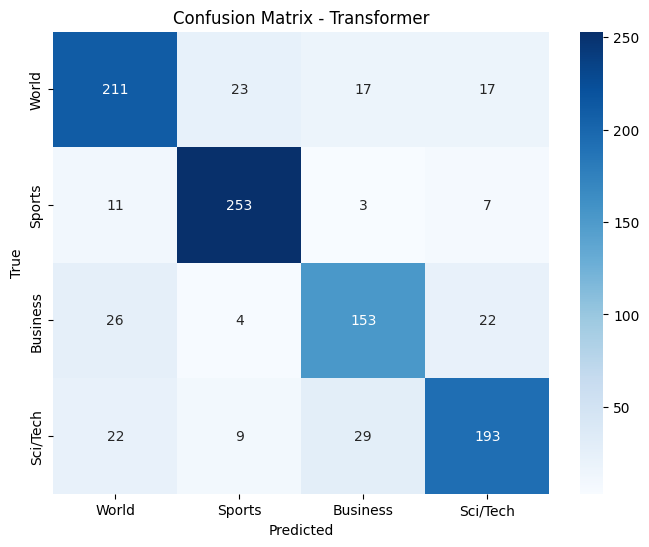

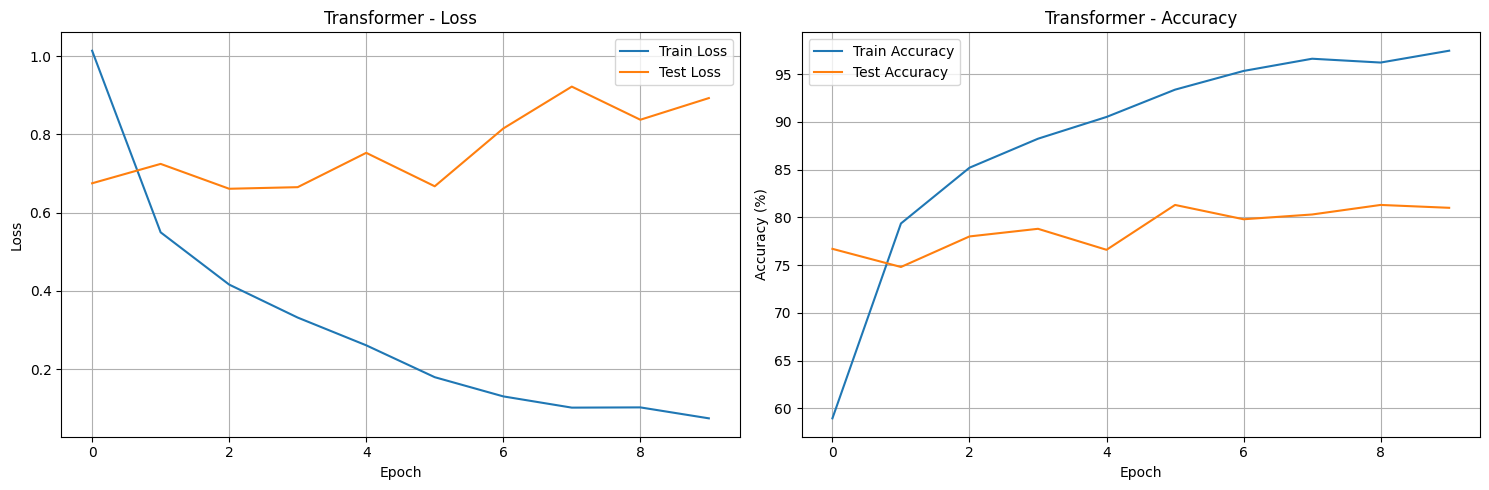

In [40]:
print("Final Transformer Results")

precision, recall, f1, _ = precision_recall_fscore_support(
    transformer_history['labels'],
    transformer_history['preds'],
    average='weighted'
)

print(f"Accuracy: {transformer_history['best_acc']:.2f}%")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")


plot_confusion_matrix(
    transformer_history['labels'],
    transformer_history['preds'],
    class_names,
    'Transformer'
)


fig, axes = plt.subplots(1, 2, figsize=(15, 5))
axes[0].plot(transformer_history['train_losses'], label='Train Loss')
axes[0].plot(transformer_history['test_losses'], label='Test Loss')
axes[0].set_title('Transformer - Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(transformer_history['train_accs'], label='Train Accuracy')
axes[1].plot(transformer_history['test_accs'], label='Test Accuracy')
axes[1].set_title('Transformer - Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()


Sample 1:
Text: <UNK> cut workforce consumer goods maker <UNK> said today would cut per cent person work force close third factories worldwide part fouryear restructuring <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD>...
True: Business | Predicted: Business


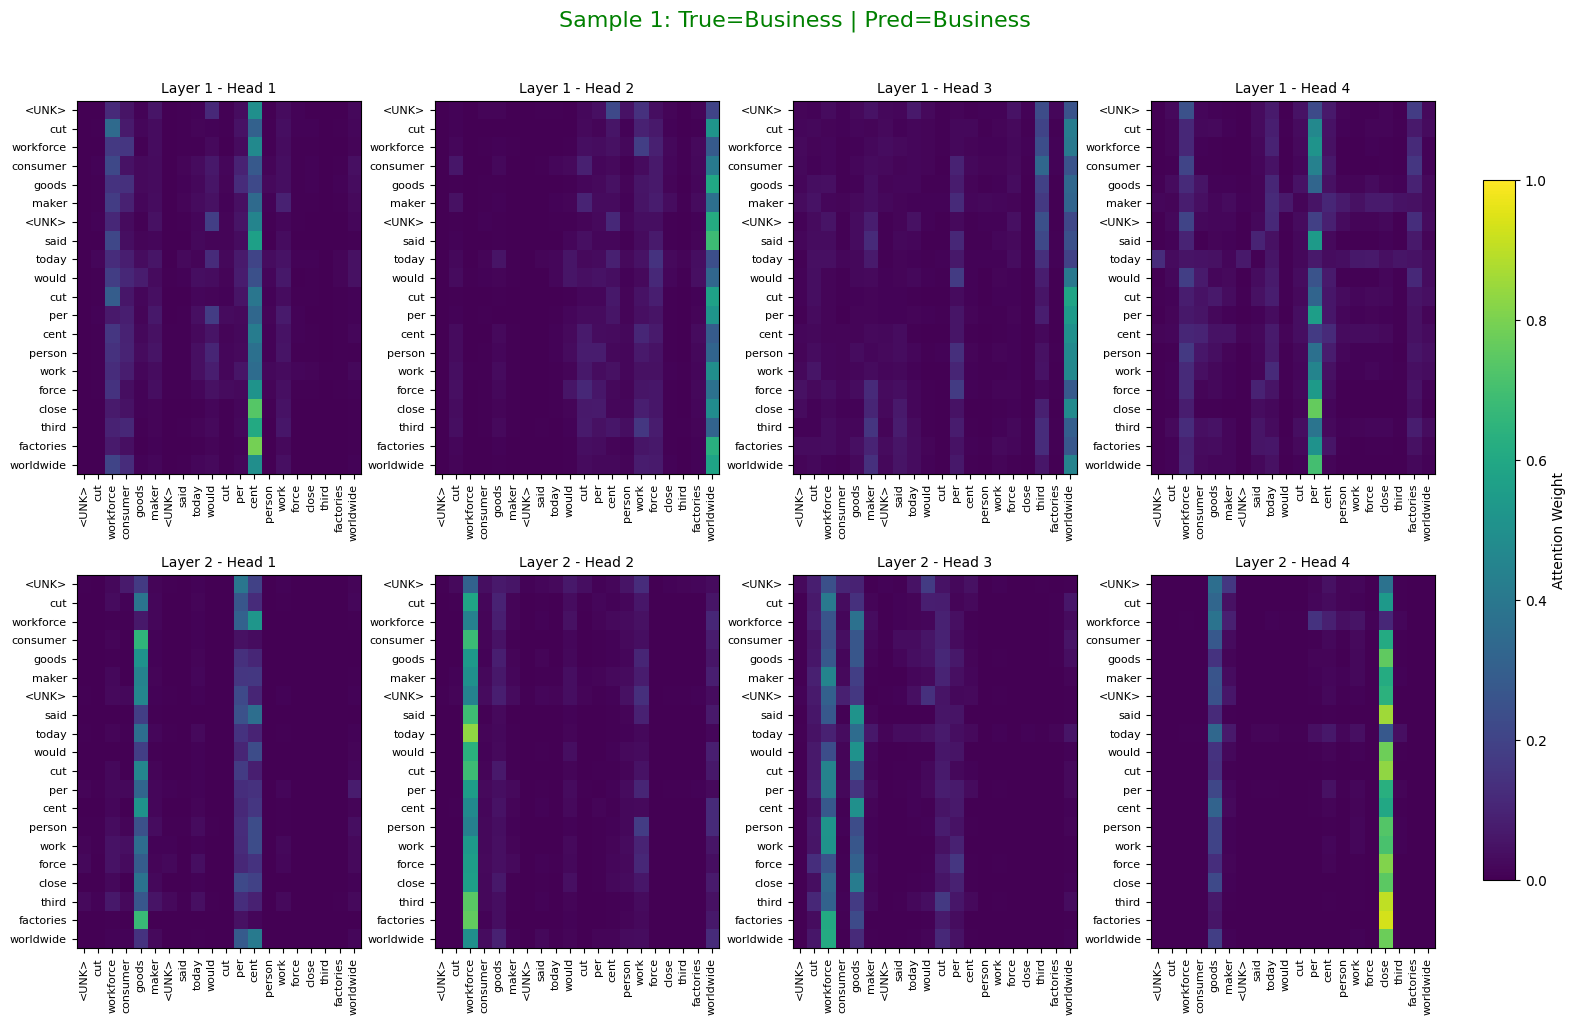


Sample 2:
Text: china says taiwan spy also operated us media beijing reuters beijing monday accused <UNK> arrested spying taiwan building <UNK> network united states said could go trial soon <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD>...
True: World | Predicted: World


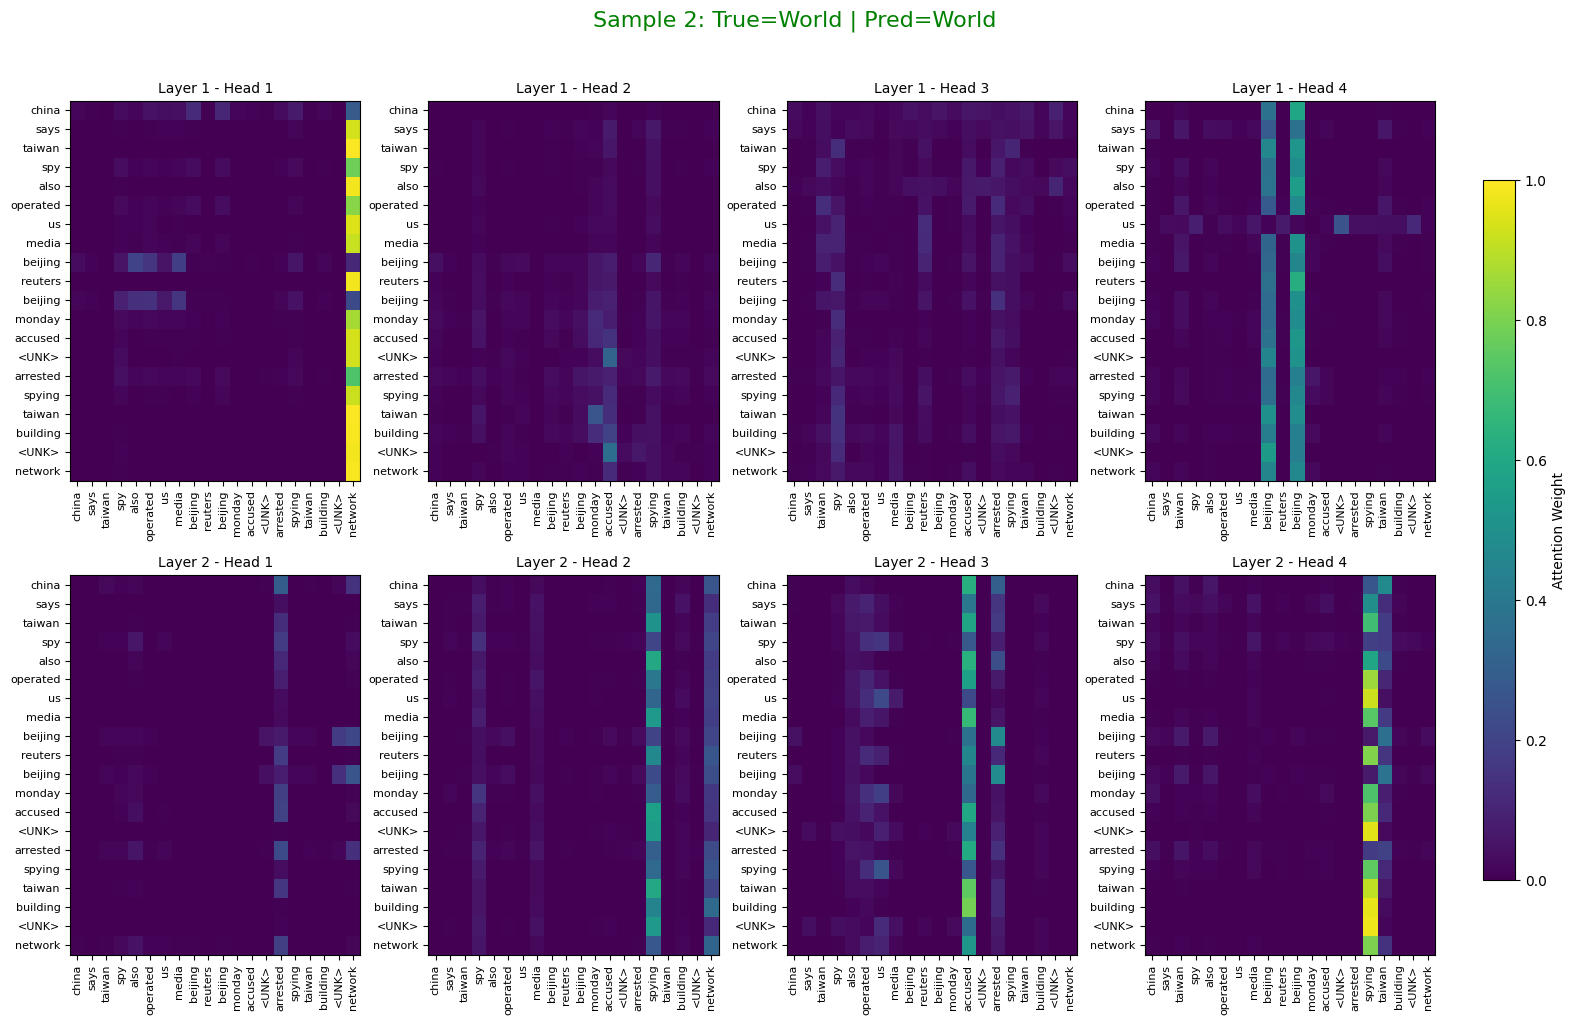


Sample 3:
Text: economic indicators declined july closely watched measure future economic activity fell july second consecutive month reinforcing evidence nations financial recovery slackening <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD>...
True: Business | Predicted: Business


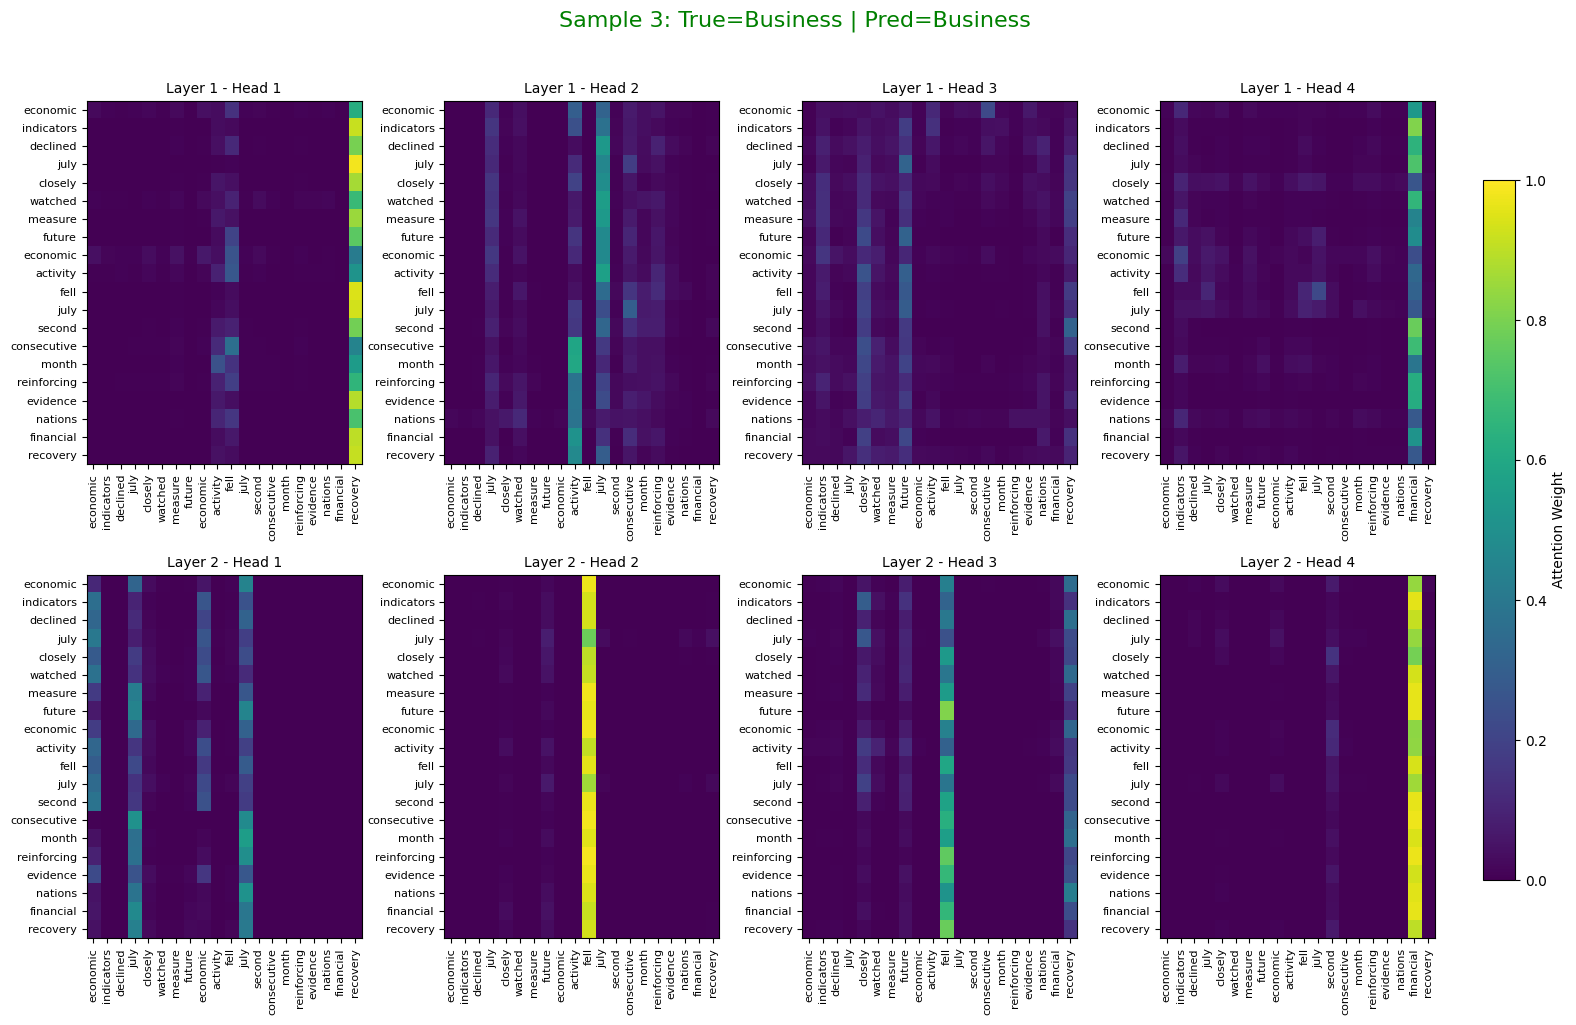


Sample 4:
Text: stopping spam source new antispam technology standards way promise hit spammers <UNK> <UNK> wallets issue ability <UNK> original source email messages major <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD>...
True: Sci/Tech | Predicted: Sci/Tech


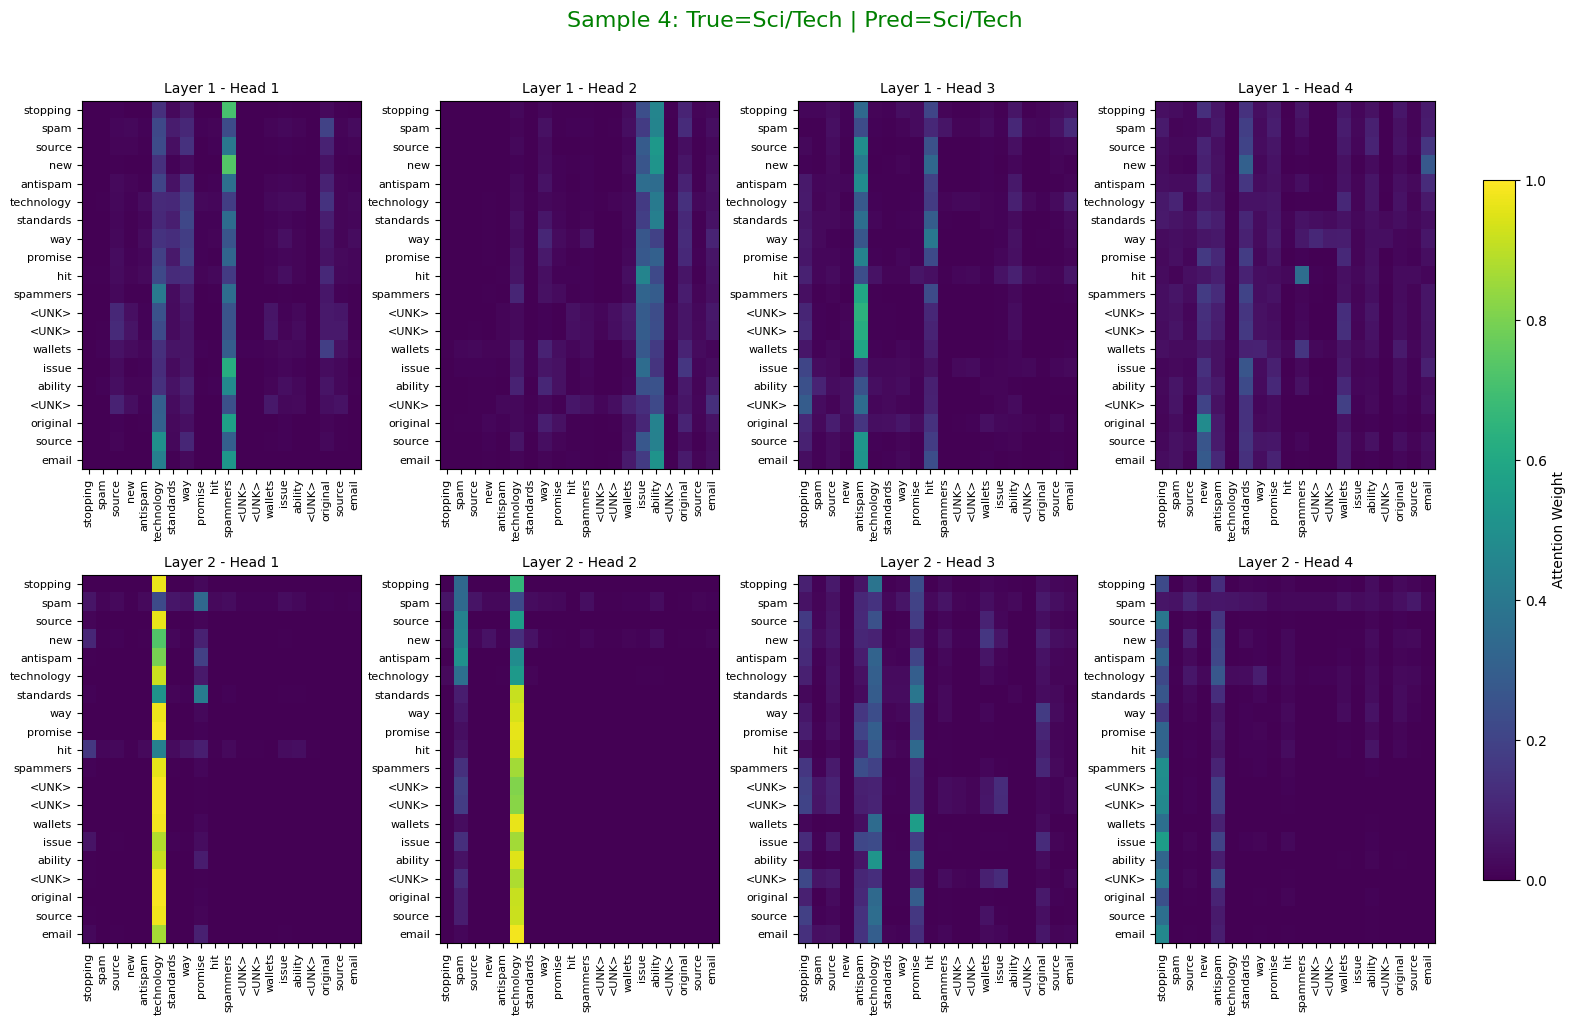


Sample 5:
Text: <UNK> telescope confirms important <UNK> discovery <UNK> <UNK> observatory confirmed <UNK> <UNK> planet orbiting <UNK> star first one spotted network astronomers using <UNK> larger ones buy stores <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD>...
True: Sci/Tech | Predicted: Sci/Tech


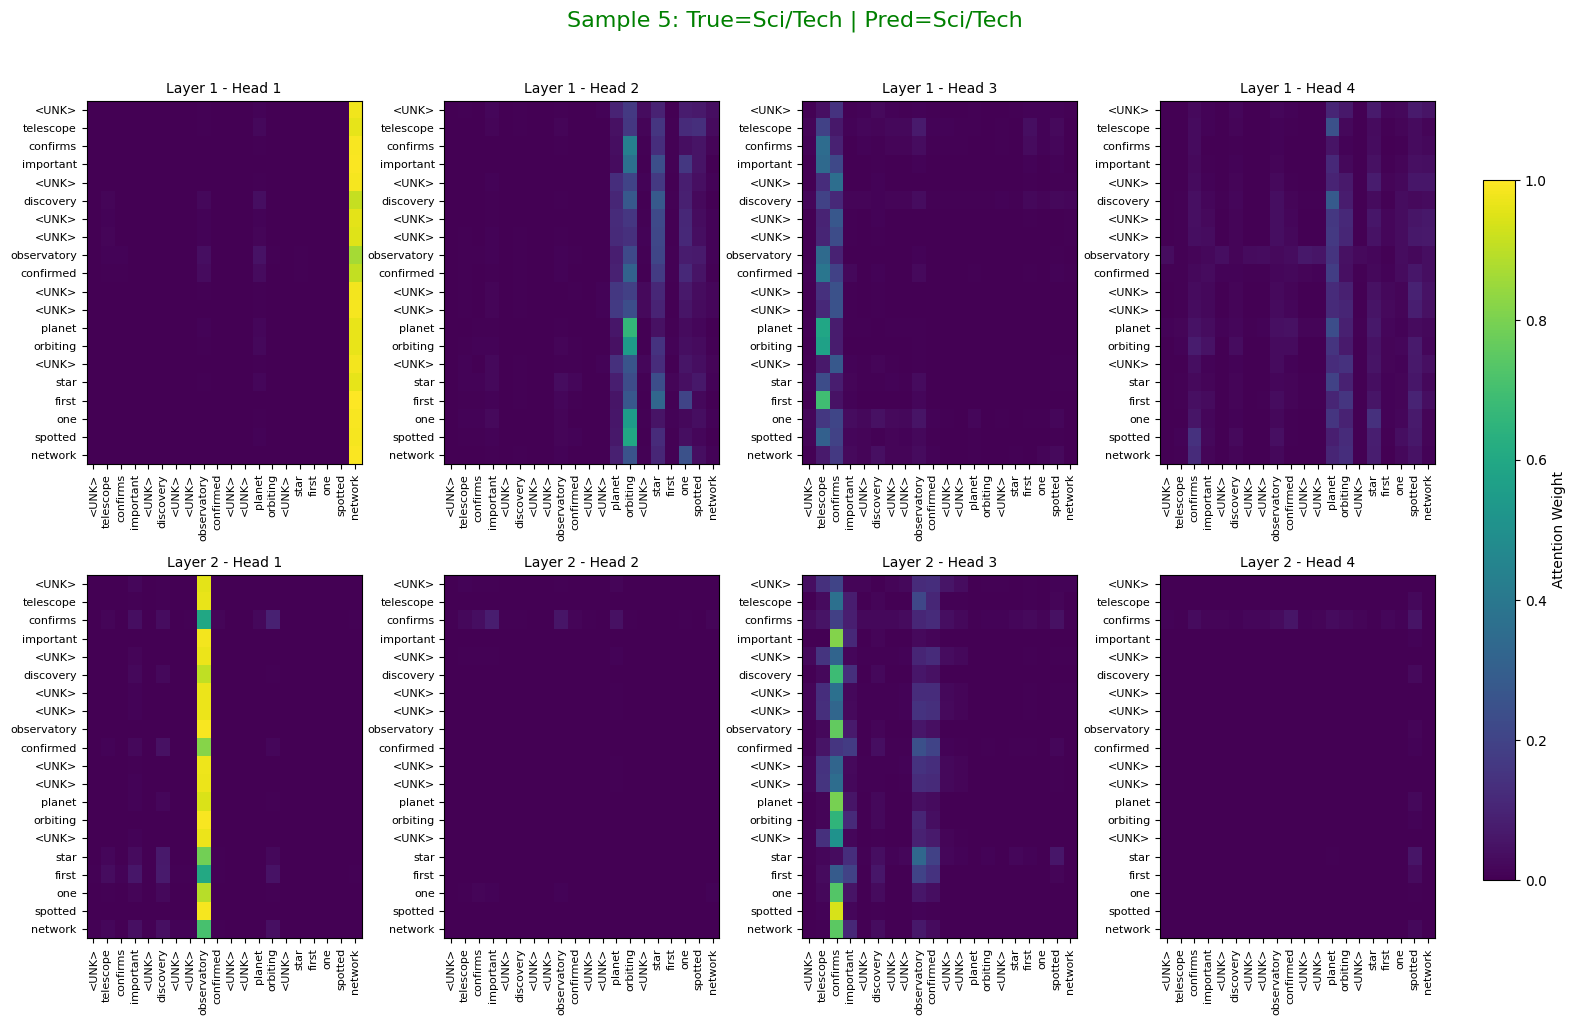

In [66]:
def extract_attention_maps(model, dataloader, device, num_samples=3):
    model.eval()
    attention_maps = []
    sample_texts = []
    sample_labels = []
    sample_preds = []
    
    with torch.no_grad():
        for i, (data, targets) in enumerate(dataloader):
            if i >= num_samples:
                break
            data, targets = data.to(device), targets.to(device)
            outputs, attns = model(data, return_attentions=True)
            
            _, predicted = torch.max(outputs, 1)
            
            attn_maps = [attn[0].cpu().numpy() for attn in attns]
            attention_maps.append(attn_maps)
            sample_texts.append(data[0].cpu().numpy())
            sample_labels.append(targets[0].item())
            sample_preds.append(predicted[0].item())
    
    return attention_maps, sample_texts, sample_labels, sample_preds


def plot_attention_maps(attention_maps, sample_texts, sample_labels, sample_preds, 
                        vocab, class_names, num_heads=4, num_layers=2):
    
    max_display = 20
    num_samples = len(attention_maps)
    
    for sample_idx in range(num_samples):
        tokens = []
        for idx in sample_texts[sample_idx]:
            token = '<UNK>'
            for word, word_idx in vocab.items():
                if word_idx == idx:
                    token = word
                    break
            tokens.append(token)
        
        true_label = class_names[sample_labels[sample_idx]]
        pred_label = class_names[sample_preds[sample_idx]]
        
        print(f"\nSample {sample_idx+1}:")
        print(f"Text: {' '.join(tokens[:50])}...")
        print(f"True: {true_label} | Predicted: {pred_label}")
        
        fig, axes = plt.subplots(num_layers, num_heads, figsize=(16, 10))
        
        if num_layers == 1:
            axes = np.array([axes])
        
        is_correct = sample_labels[sample_idx] == sample_preds[sample_idx]
        fig.suptitle(f'Sample {sample_idx+1}: True={true_label} | Pred={pred_label}',
                     fontsize=16, y=1.02, color='green' if is_correct else 'red')
        
        for layer_idx in range(num_layers):
            for head_idx in range(num_heads):
                ax = axes[layer_idx, head_idx]
                
                attn_map = attention_maps[sample_idx][layer_idx][head_idx]
                seq_len = min(attn_map.shape[0], max_display)
                attn_map_display = attn_map[:seq_len, :seq_len]
                
                im = ax.imshow(attn_map_display, cmap='viridis', aspect='auto', vmin=0, vmax=1)
                ax.set_title(f'Layer {layer_idx+1} - Head {head_idx+1}', fontsize=10)
                
                if seq_len <= 20:
                    tick_pos = list(range(seq_len))
                    ax.set_xticks(tick_pos)
                    ax.set_yticks(tick_pos)
                    ax.set_xticklabels(tokens[:seq_len], rotation=90, fontsize=8)
                    ax.set_yticklabels(tokens[:seq_len], fontsize=8)
                else:
                    ax.set_xticks([])
                    ax.set_yticks([])
        
        plt.tight_layout()
        plt.subplots_adjust(right=0.9)
        cbar_ax = fig.add_axes([0.93, 0.15, 0.02, 0.7])
        fig.colorbar(im, cax=cbar_ax, label='Attention Weight')
        plt.show()


correct_samples = []

with torch.no_grad():
    for data, targets in test_loader:
        if len(correct_samples) >= 5:
            break
        data, targets = data.to(device), targets.to(device)
        outputs = transformer_model(data)
        _, preds = torch.max(outputs, 1)
        
        for i in range(len(targets)):
            if targets[i] == preds[i] and len(correct_samples) < 5:
                correct_samples.append((data[i:i+1], targets[i:i+1]))


class CorrectSamplesDataset(Dataset):
    def __init__(self, samples):
        self.samples = samples
    
    def __len__(self):
        return len(self.samples)
    
    def __getitem__(self, idx):
        data, target = self.samples[idx]
        return data[0], target[0]

correct_dataset = CorrectSamplesDataset(correct_samples)
correct_loader = DataLoader(correct_dataset, batch_size=1, shuffle=False)

attn_maps, sample_texts, sample_labels, sample_preds = extract_attention_maps(
    transformer_model, correct_loader, device, num_samples=5
)

plot_attention_maps(attn_maps, sample_texts, sample_labels, sample_preds, 
                    vocab, class_names, num_heads=4, num_layers=2)
